In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

#Text Dataset


In [ ]:
from datasets import load_dataset

ds = load_dataset("vbhaskar/go_emotions", "simplified")
print("data loaded sucessfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

data loaded sucessfully


In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
ds['train'].features

{'text': Value('string'),
 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])),
 'id': Value('string')}

In [ ]:
df = ds["train"].to_pandas()
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


#Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    43410 non-null  object
 1   labels  43410 non-null  object
 2   id      43410 non-null  object
dtypes: object(3)
memory usage: 1017.6+ KB


In [ ]:
num_labels = 28

def encode_labels(label_list):
    multi_hot = [0] * num_labels
    for label in label_list:
        multi_hot[label] = 1
    return multi_hot

df["labels"] = df["labels"].apply(encode_labels)

In [ ]:
df["labels"].head()

,labels
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
label_counts = np.sum(df["labels"].tolist(), axis=0)

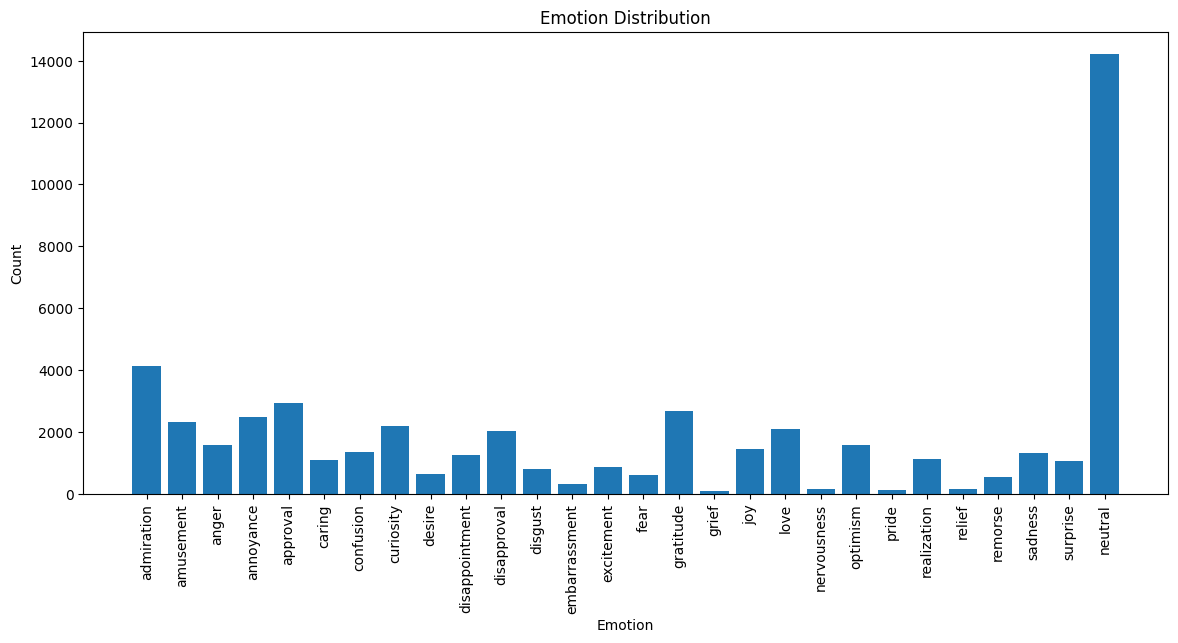

In [ ]:
emotion_labels = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral"
]

plt.figure(figsize=(14,6))
plt.bar(emotion_labels, label_counts)

plt.xticks(rotation=90)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

In [ ]:
#Text length
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

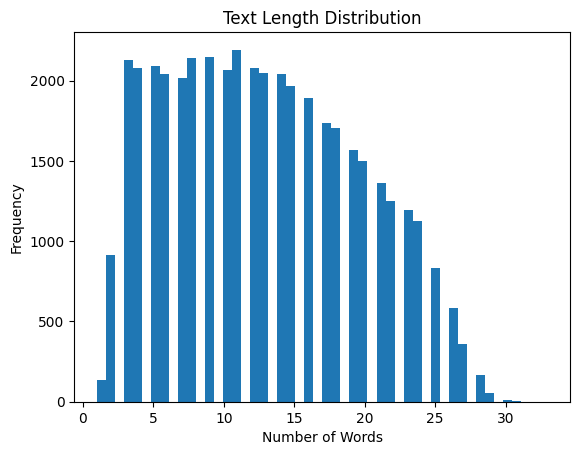

In [ ]:
plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import Counter

all_words = " ".join(df["text"]).split()
word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('the', 16294), ('I', 14933), ('to', 12267), ('a', 11920), ('and', 8186), ('is', 7799), ('you', 7002), ('of', 6955), ('that', 6322), ('[NAME]', 5743), ('for', 5459), ('in', 5459), ('it', 5162), ('this', 4330), ('was', 3764), ('be', 3398), ('on', 3309), ('my', 3129), ('have', 3107), ('like', 3033)]


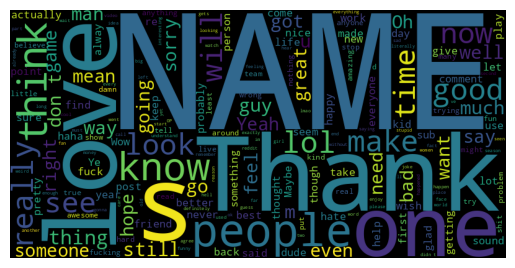

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [ ]:
df["num_labels"] = df["labels"].apply(lambda x: sum(x))

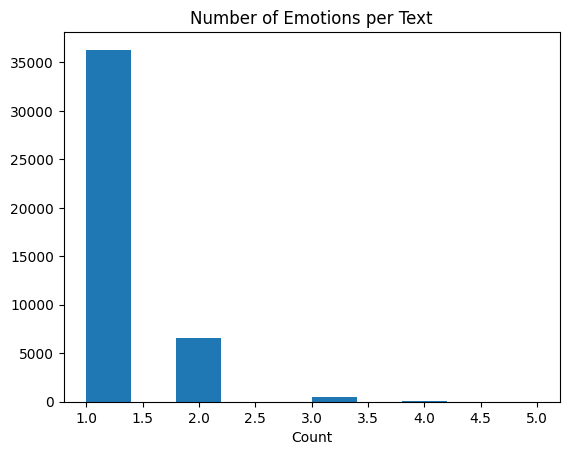

In [ ]:
plt.hist(df["num_labels"], bins=10)
plt.title("Number of Emotions per Text")
plt.xlabel("Count")
plt.show()

#Preprocessing

In [ ]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove links
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    return text

In [ ]:
num_labels = 28

def encode_labels(example):
    multi_hot = [0] * num_labels
    for label in example["labels"]:
        multi_hot[label] = 1
    example["labels"] = multi_hot
    return example

ds = ds.map(encode_labels)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [ ]:
print(ds["train"][0]["labels"])
print(len(ds["train"][0]["labels"]))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
28


In [ ]:
ds = ds.map(lambda x: {"text": clean_text(x["text"])})
print('Mapped')

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

Mapped


In [ ]:
ds = ds.remove_columns("id")

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

ds = ds.map(tokenize, batched=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [ ]:
import torch

ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
    format_kwargs={"dtype": torch.float}
)

In [ ]:
print(len(ds["train"][0]["labels"]))
print(ds["train"][0]["labels"].dtype)

28
torch.float32


In [ ]:
ds = ds.map(lambda x: {"labels": [float(i) for i in x["labels"]]})

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [ ]:
ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
print(type(ds["train"][0]["labels"][0]))

<class 'torch.Tensor'>


In [ ]:
ds["train"][0]["labels"].dtype

torch.int64

In [ ]:
ds = ds.map(lambda x: {"labels": [float(i) for i in x["labels"]]})

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [ ]:
ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
ds["train"][0]

{'labels': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 1]),
 'input_ids': tensor([ 101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 2102, 2031, 2000, 5660,
         2870,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'at

In [ ]:
ds["train"][0]["labels"].dtype

torch.int64

In [ ]:
from datasets import Features, Sequence, Value

new_features = Features({
    "input_ids": Sequence(Value("int64")),
    "attention_mask": Sequence(Value("int64")),
    "labels": Sequence(Value("float32")),
})

In [ ]:
ds = ds.remove_columns(["text", "token_type_ids"])

In [ ]:
from datasets import Features, Sequence, Value

new_features = Features({
    "input_ids": Sequence(Value("int64")),
    "attention_mask": Sequence(Value("int64")),
    "labels": Sequence(Value("float32")),
})

ds = ds.cast(new_features)

Casting the dataset:   0%|          | 0/43410 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/5426 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [ ]:
ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
ds["train"][0]["labels"].dtype

torch.float32

In [ ]:
df = ds["train"].to_pandas()
df.head()

,input_ids,attention_mask,labels
0,"[101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"[101, 2085, 2065, 2002, 2515, 2125, 2370, 3071...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"[101, 2339, 1996, 6616, 2003, 3016, 3238, 1116...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"[101, 2000, 2191, 2014, 2514, 5561, 102, 0, 0,...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"[101, 6530, 2670, 14071, 11451, 102, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


input_ids
 This is the numerical version of  sentence

token_type_ids
Used to distinguish sentence pairs

attention_mask
Tells model what to focus on

#BERT

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.metrics import f1_score

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=28,
    problem_type="multi_label_classification"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:

model.to("cuda")

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    f1 = f1_score(labels, preds, average="micro")
    return {"f1": f1}

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.095140,0.088566,0.541818
2,0.081592,0.084937,0.570569
3,0.069969,0.086062,0.578596


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=16281, training_loss=0.08947679643717088, metrics={'train_runtime': 1850.648, 'train_samples_per_second': 70.37, 'train_steps_per_second': 8.797, 'total_flos': 4314807064442880.0, 'train_loss': 0.08947679643717088, 'epoch': 3.0})

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def predict_emotion(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    return probs

In [ ]:
def get_top_emotions(probs, top_k=3):
    top_indices = probs.argsort()[-top_k:][::-1]
    return [(emotion_labels[i], float(probs[i])) for i in top_indices]

In [ ]:
def get_emotions(probs, threshold=0.2):
    emotions = []

    for i, p in enumerate(probs):
        if p > threshold:
            emotions.append((emotion_labels[i], float(p)))

    if len(emotions) == 0:
        top_indices = probs.argsort()[-3:][::-1]
        emotions = [(emotion_labels[i], float(probs[i])) for i in top_indices]

    return emotions

In [ ]:
def interpret_emotion(emotions):
    positive = ["joy", "optimism", "admiration", "approval", "gratitude","love"]
    negative = ["sadness", "grief"]

    for emo, score in emotions:
        if emo in positive:
            return "Positive emotional state"
        elif emo in negative:
            return "Negative emotional state"

    return "Neutral or mixed emotions"

In [ ]:

# text=input("Enter your sentence:")
# probs=predict_emotion(text)
# emotions=get_emotions(probs)
# print("\nDetected Emotions:")
# for emo,score in emotions:
#   print(f"{emo}:{score:.2f}")
# interpretation=interpret_emotion(emotions)
# print("\nInterpretation:",interpretation)

In [ ]:
from sklearn.metrics import classification_report

predictions = trainer.predict(ds["test"])
logits = predictions.predictions
true_labels = predictions.label_ids

In [ ]:
probs = 1 / (1 + np.exp(-logits))  # sigmoid

In [ ]:
threshold = 0.3
preds = (probs > threshold).astype(int)

In [ ]:
print(classification_report(true_labels, preds, target_names=emotion_labels))

                precision    recall  f1-score   support

    admiration       0.63      0.77      0.69       504
     amusement       0.77      0.92      0.84       264
         anger       0.49      0.50      0.49       198
     annoyance       0.40      0.35      0.37       320
      approval       0.42      0.38      0.40       351
        caring       0.45      0.42      0.43       135
     confusion       0.50      0.45      0.47       153
     curiosity       0.46      0.60      0.52       284
        desire       0.67      0.42      0.52        83
disappointment       0.41      0.23      0.30       151
   disapproval       0.40      0.43      0.42       267
       disgust       0.55      0.50      0.52       123
 embarrassment       0.78      0.38      0.51        37
    excitement       0.47      0.36      0.41       103
          fear       0.67      0.72      0.70        78
     gratitude       0.92      0.92      0.92       352
         grief       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
trainer.save_model("my_emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
tokenizer.save_pretrained("my_emotion_model")

('my_emotion_model/tokenizer_config.json', 'my_emotion_model/tokenizer.json')

#Image Dataset

In [ ]:
import os
import kagglehub
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:01<00:00, 62.4MB/s]



In [ ]:
!unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
import os
os.listdir()

['.config',
 'results',
 'fer2013.zip',
 'test',
 'train',
 'my_emotion_model',
 'sample_data']

In [ ]:
train_path = "train"

for folder in os.listdir(train_path):
    print(folder)

angry
happy
fear
neutral
sad
surprise
disgust


In [ ]:
class_counts = {}

for cls in os.listdir(train_path):
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

print(class_counts)

{'angry': 3995, 'happy': 7215, 'fear': 4097, 'neutral': 4965, 'sad': 4830, 'surprise': 3171, 'disgust': 436}


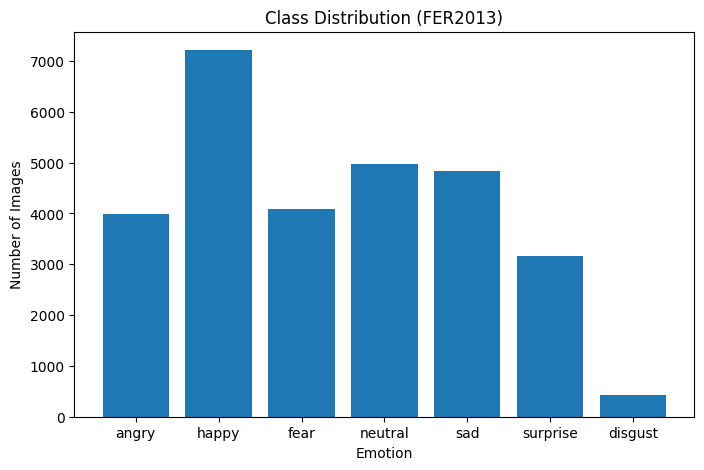

In [ ]:

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution (FER2013)")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

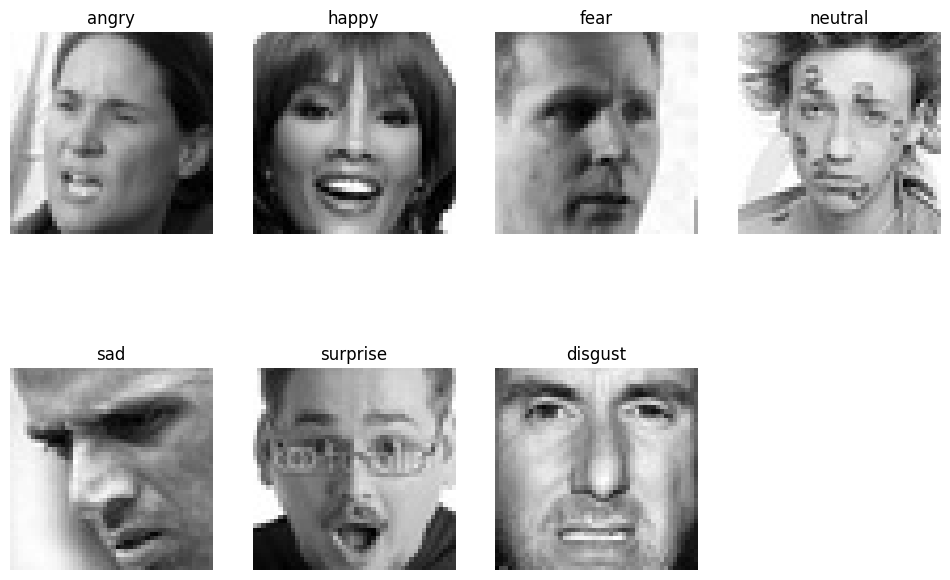

In [ ]:
from PIL import Image
import random

plt.figure(figsize=(12,8))

for i, cls in enumerate(class_counts.keys()):
    img_path = os.path.join(train_path, cls, random.choice(os.listdir(os.path.join(train_path, cls))))
    img = Image.open(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
img = Image.open(img_path)
print(img.size)

(48, 48)


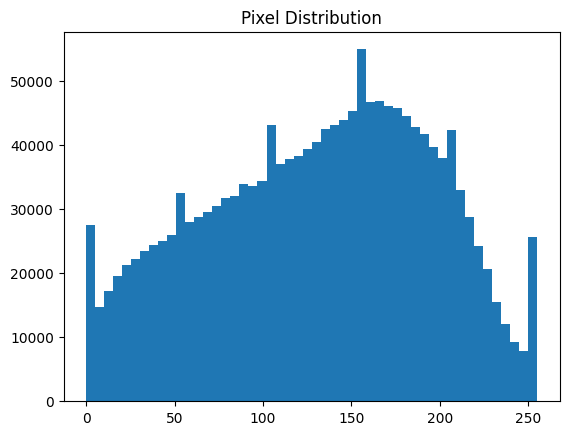

In [ ]:
pixels = []

for cls in os.listdir(train_path):
    for img_name in os.listdir(os.path.join(train_path, cls))[:100]:
        img = Image.open(os.path.join(train_path, cls, img_name))
        pixels.extend(np.array(img).flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Distribution")
plt.show()

In [ ]:
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
print(sorted_counts)

{'happy': 7215, 'neutral': 4965, 'sad': 4830, 'fear': 4097, 'angry': 3995, 'surprise': 3171, 'disgust': 436}


#Preprocessing


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensure 1 channel
    transforms.Resize((48, 48)),                 # same size
    transforms.ToTensor(),                       # convert to tensor (0–1)
])

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),

    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.ImageFolder("train", transform=train_transform)
test_data = datasets.ImageFolder("test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

In [ ]:
import torch
from sklearn.utils.class_weight import compute_class_weight

labels = [label for _, label in train_data]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

#CNN

In [ ]:
# import torch.nn as nn
# import torch.nn.functional as F

# class EmotionCNN(nn.Module):
#     def __init__(self):
#         super(EmotionCNN, self).__init__()

#         self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)

#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)

#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)

#         self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)

#         self.pool = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.3)  # reduced dropout

#         self.fc1 = nn.Linear(256 * 3 * 3, 512)
#         self.fc2 = nn.Linear(512, 7)

#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 48 → 24
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 24 → 12
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 12 → 6
#         x = self.pool(F.relu(self.bn4(self.conv4(x))))  # 6 → 3

#         x = x.view(x.size(0), -1)

#         x = self.dropout(F.relu(self.fc1(x)))
#         x = self.fc2(x)

#         return x

In [ ]:
# import torch.optim as optim

# model = EmotionCNN().to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights)
# optimizer = optim.Adam(model.parameters(), lr=0.0003)


# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', patience=2, factor=0.5
# )

In [ ]:
# num_epochs = 30

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0

#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)

#         optimizer.zero_grad()

#         outputs = model(images)
#         loss = criterion(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item() * images.size(0)

#     epoch_loss = running_loss / len(train_loader.dataset)

#     # Evaluation
#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)

#             outputs = model(images)
#             _, predicted = torch.max(outputs, 1)

#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#     acc = 100 * correct / total

#     scheduler.step(acc)

#     print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}, Accuracy: {acc:.2f}%")

In [ ]:
# best_acc = 0

# if acc > best_acc:
#     best_acc = acc
#     torch.save(model.state_dict(), "best_model.pth")

In [ ]:
# model.eval()

# y_pred = []
# y_true = []

# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)

#         outputs = model(images)
#         _, predicted = torch.max(outputs, 1)

#         y_pred.extend(predicted.cpu().numpy())
#         y_true.extend(labels.numpy())

In [ ]:
# y_pred = np.array(y_pred)
# y_true = np.array(y_true)

# accuracy = (y_pred == y_true).mean() * 100
# print(f"Accuracy: {accuracy:.2f}%")

In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(8,6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=train_data.classes,
#             yticklabels=train_data.classes)

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

In [ ]:
# from sklearn.metrics import classification_report

# print(classification_report(y_true, y_pred, target_names=train_data.classes))

In [ ]:
# !pip install torchsummary

In [ ]:
# from torchsummary import summary

# summary(model, (1, 48, 48))

#ResNet18

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # improves accuracy
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(root="train", transform=transform)
val_dataset   = datasets.ImageFolder(root="test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
model_res = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [ ]:
num_classes = len(train_dataset.classes)

model_res.fc = nn.Linear(model_res.fc.in_features, num_classes)
model_res = model_res.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_res.parameters(), lr=0.0001)

In [81]:
num_epochs = 10

for epoch in range(num_epochs):
    model_res.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_res(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

    # Validation
    model_res.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model_res(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Validation Accuracy: {val_acc:.2f}%")

Epoch [1/10] Loss: 1026.3041, Accuracy: 56.72%
Validation Accuracy: 62.04%
Epoch [2/10] Loss: 842.0898, Accuracy: 65.02%
Validation Accuracy: 64.27%
Epoch [3/10] Loss: 756.1356, Accuracy: 68.85%
Validation Accuracy: 66.97%
Epoch [4/10] Loss: 679.4208, Accuracy: 71.96%
Validation Accuracy: 67.28%
Epoch [5/10] Loss: 609.8446, Accuracy: 75.04%
Validation Accuracy: 67.08%
Epoch [6/10] Loss: 531.9672, Accuracy: 78.39%
Validation Accuracy: 67.79%
Epoch [7/10] Loss: 464.1467, Accuracy: 81.30%
Validation Accuracy: 68.15%
Epoch [8/10] Loss: 402.3770, Accuracy: 83.73%
Validation Accuracy: 66.56%
Epoch [9/10] Loss: 349.0207, Accuracy: 86.03%
Validation Accuracy: 67.43%
Epoch [10/10] Loss: 304.1014, Accuracy: 88.02%
Validation Accuracy: 67.11%


In [82]:
torch.save(model_res.state_dict(), "resnet_model.pth")

#Combined Model

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [84]:
base_path = "/content/drive/MyDrive/emotion_app"

os.makedirs(f"{base_path}/text_model", exist_ok=True)
os.makedirs(f"{base_path}/image_model", exist_ok=True)
os.makedirs(f"{base_path}/labels", exist_ok=True)

print("Folders created!")

Folders created!


In [85]:
#save text model
trainer.save_model(f"{base_path}/text_model")
tokenizer.save_pretrained(f"{base_path}/text_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/emotion_app/text_model/tokenizer_config.json',
 '/content/drive/MyDrive/emotion_app/text_model/tokenizer.json')

In [86]:
#Image model
torch.save(model_res.state_dict(), f"{base_path}/image_model/resnet_model.pth")

In [87]:
#Save Labels
import json

text_class_names = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion',
    'curiosity','desire','disappointment','disapproval','disgust','embarrassment',
    'excitement','fear','gratitude','grief','joy','love','nervousness','optimism',
    'pride','realization','relief','remorse','sadness','surprise','neutral'
]

image_class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

with open(f"{base_path}/labels/text_labels.json", "w") as f:
    json.dump(text_class_names, f)

with open(f"{base_path}/labels/image_labels.json", "w") as f:
    json.dump(image_class_names, f)

print("Labels saved!")

Labels saved!


In [88]:
#combned model class
import torch
import json
import cv2
from PIL import Image
from torchvision import transforms, models
from transformers import AutoTokenizer, AutoModelForSequenceClassification


class EmotionAI:

    def __init__(self, base_path, device=None):

        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")

        # Load labels
        with open(f"{base_path}/labels/text_labels.json") as f:
            self.text_labels = json.load(f)

        with open(f"{base_path}/labels/image_labels.json") as f:
            self.image_labels = json.load(f)

        # Load text model
        self.tokenizer = AutoTokenizer.from_pretrained(f"{base_path}/text_model")
        self.text_model = AutoModelForSequenceClassification.from_pretrained(
            f"{base_path}/text_model"
        ).to(self.device)

        self.text_model.eval()

        # Load image model
        self.image_model = models.resnet18()
        self.image_model.fc = torch.nn.Linear(
            self.image_model.fc.in_features, len(self.image_labels)
        )

        self.image_model.load_state_dict(
            torch.load(f"{base_path}/image_model/resnet_model.pth", map_location=self.device)
        )

        self.image_model.to(self.device)
        self.image_model.eval()

        # Transform
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

        # Face detector
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )

    def map_to_fer(self, label):
        if label in ['anger', 'annoyance']:
            return 'angry'
        elif label in ['disgust']:
            return 'disgust'
        elif label in ['fear', 'nervousness']:
            return 'fear'
        elif label in ['joy', 'amusement', 'love', 'excitement', 'optimism']:
            return 'happy'
        elif label in ['sadness', 'grief', 'disappointment', 'remorse']:
            return 'sad'
        elif label in ['surprise', 'realization']:
            return 'surprise'
        else:
            return 'neutral'

    def predict_text(self, text):

        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True, padding=True
        ).to(self.device)

        with torch.no_grad():
            outputs = self.text_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)[0]

        topk = torch.topk(probs, 5)

        seen = set()
        results = []

        for idx in topk.indices:
            label = self.text_labels[idx]
            confidence = probs[idx].item()

            mapped = self.map_to_fer(label)

            if mapped not in seen:
                seen.add(mapped)
                results.append((mapped, confidence))

            if len(results) == 2:
                break

        return results

    def predict_image(self, image_path):

        image_cv = cv2.imread(image_path)
        gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

        faces = self.face_cascade.detectMultiScale(gray, 1.3, 5)

        if len(faces) > 0:
            (x, y, w, h) = faces[0]
            face = image_cv[y:y+h, x:x+w]
            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(face)
        else:
            image = Image.open(image_path).convert("RGB")

        image = self.transform(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            outputs = self.image_model(image)
            probs = torch.softmax(outputs, dim=1)[0]

        top2 = torch.topk(probs, 2)

        results = []
        for idx in top2.indices:
            label = self.image_labels[idx]
            confidence = probs[idx].item()
            results.append((label, confidence))

        return results

    def predict(self, user_input):

        if user_input.lower().endswith(('.jpg', '.png', '.jpeg')):
            return self.predict_image(user_input)
        else:
            return self.predict_text(user_input)

In [89]:
app = EmotionAI(base_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

#Response Generator

In [90]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [91]:
def adjust_emotion(user_input, predicted_emotion):
    text = user_input.lower()

    if any(word in text for word in ["happy", "won", "selected", "achieved", "success"]):
        return "happy"

    if any(word in text for word in ["sad", "lonely", "bad", "tired"]):
        return "sad"

    if any(word in text for word in ["angry", "frustrated", "hate"]):
        return "angry"

    return predicted_emotion

In [92]:
def adjust_emotion(user_input, predicted_emotion):
    text = user_input.lower()

    # negative context first (priority)
    if any(w in text for w in ["tired", "exhausted", "burnt", "drained", "stress", "overwhelmed"]):
        return "sad"

    #  positive context
    if any(w in text for w in ["job", "selected", "won", "achieved", "success"]):
        return "happy"

    #  anger
    if any(w in text for w in ["angry", "frustrated", "hate"]):
        return "angry"

    return predicted_emotion

In [93]:
def adjust_emotion(user_input, predicted_emotion):
    text = user_input.lower()

    #  NEGATIVE FIRST (highest priority)
    if any(w in text for w in ["tired", "exhausted", "burnt", "drained", "stress", "overwhelmed"]):
        return "sad"

    #  anger
    if any(w in text for w in ["angry", "frustrated", "hate"]):
        return "angry"

    # positive AFTER negative check
    if any(w in text for w in ["job", "selected", "won", "achieved", "success"]):
        return "happy"

    return predicted_emotion

In [94]:

def adjust_emotion(user_input, predicted_emotion):
    text = user_input.lower()

    # negative first
    if any(w in text for w in ["tired", "exhausted", "burnt", "drained", "stress", "overwhelmed"]):
        return "sad"

    #  anger
    if any(w in text for w in ["angry", "frustrated", "hate"]):
        return "angry"

    #  positive
    if any(w in text for w in ["job", "selected", "won", "achieved", "success", "happy"]):
        return "happy"

    return predicted_emotion

In [95]:
def build_prompt(user_input, emotion):
    return f"""
You are a helpful and emotionally intelligent assistant.

The user feels {emotion}.
Respond clearly and naturally.

Rules:
- Keep it short (1 sentence)
- Be supportive
- Do NOT repeat the user
- Do NOT generate random or nonsense text

User: {user_input}
Assistant:
"""

In [96]:
import random

def generate_response(user_input, emotions):

    text = user_input.lower()
    emotion = adjust_emotion(user_input, emotions[0][0])

    #  polite responses
    if "thank you" in text or "thanks" in text:
        return "You're welcome 😊 I'm here if you want to talk more."

    # greetings
    if text in ["hi", "hello", "hey"]:
        return "Hey there! How are you feeling today?"

    #  context-aware responses

    # job + negative
    if "job" in text and any(w in text for w in ["tired", "exhausted", "stress", "overwhelmed"]):
        return "That sounds really exhausting… work can get overwhelming. What part of it is draining you the most?"

    # job + positive
    if "job" in text:
        return "That's amazing! Congratulations 🎉 What kind of job is it?"

    # lonely
    if "lonely" in text:
        return "I'm really sorry you're feeling lonely. Do you want to talk about it?"

    # tired general
    if "tired" in text:
        return "That sounds exhausting… do you want to share what's been draining you?"

    # 💬 emotion-based fallback
    responses = {
        "happy": [
            "That's great to hear! What made you feel this way?",
            "I love that 😊 Tell me more!",
        ],
        "sad": [
            "I'm really sorry you're feeling this way. Want to talk about it?",
            "That sounds tough… I'm here for you.",
        ],
        "angry": [
            "That sounds frustrating. What happened?",
            "I get why you'd feel that way. Want to talk it out?",
        ],
        "neutral": [
            "I see. Tell me more about it.",
            "Got it. What’s on your mind?",
        ]
    }

    return random.choice(responses.get(emotion, ["I'm here for you."]))

In [97]:
def run_chatbot():
    print("🤖 Emotion AI Chatbot (type 'exit' to quit)\n")

    while True:
        user_input = input("You: ").strip()

        if user_input.lower() == "exit":
            print("Bot: Bye! 👋")
            break

        # 🔹 detect emotion
        emotions = app.predict(user_input)

        # 🔹 adjust emotion
        emotion = adjust_emotion(user_input, emotions[0][0])

        print("\nDetected Emotion:", emotion)

        try:
            # 🖼 image input
            if user_input.lower().endswith(('.jpg', '.png', '.jpeg')):
                response = f"It looks like you're feeling {emotion} in this image. Want to tell me what’s going on?"

            # 💬 text input
            else:
                response = generate_response(user_input, emotions)

        except Exception as e:
            print("⚠️ Error:", e)
            response = "I'm here for you. Tell me more."

        print("Bot:", response, "\n")

In [98]:
run_chatbot()

🤖 Emotion AI Chatbot (type 'exit' to quit)

You: hey

Detected Emotion: neutral
Bot: Hey there! How are you feeling today? 

You: i am feeling good

Detected Emotion: happy
Bot: That's great to hear! What made you feel this way? 

You: i wake up in the morning

Detected Emotion: neutral
Bot: I see. Tell me more about it. 

You: exit
Bot: Bye! 👋


#Deployment

In [99]:
!pip install gradio

In [100]:
import gradio as gr

def chat_interface(message, history):

    emotions = app.predict(message)
    emotion = adjust_emotion(message, emotions[0][0])

    if message.lower().endswith(('.jpg', '.png', '.jpeg')):
        response = f"It looks like you're feeling {emotion} in this image. Want to tell me what’s going on?"
    else:
        response = generate_response(message, emotions)

    reply = f"🧠 Emotion: {emotion}\n\n💬 {response}"

    history.append((message, reply))
    return "", history


with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("## 🤖 Emotion AI Chatbot")
    gr.Markdown("Talk to a chatbot that understands your emotions")

    chatbot = gr.Chatbot()
    msg = gr.Textbox(placeholder="Type your message...", scale=4)
    clear = gr.Button("Clear Chat")

    msg.submit(chat_interface, [msg, chatbot], [msg, chatbot])
    clear.click(lambda: None, None, chatbot, queue=False)

demo.launch()

/tmp/ipykernel_5030/1870509195.py:19: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_5030/1870509195.py:24: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot()
/tmp/ipykernel_5030/1870509195.py:24: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4bbd9981d755ca67ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [101]:
import gradio as gr

def chat_interface(message, image, history):

    # 🖼 If image is uploaded
    if image is not None:
        emotions = app.predict(image)
        emotion = emotions[0][0]

        response = f"It looks like you're feeling {emotion} in this image. Want to tell me what’s going on?"

        user_display = "📷 Image uploaded"

    # 💬 Text input
    else:
        emotions = app.predict(message)
        emotion = adjust_emotion(message, emotions[0][0])
        response = generate_response(message, emotions)

        user_display = message

    reply = f"🧠 Emotion: {emotion}\n\n💬 {response}"

    history.append((user_display, reply))

    return "", None, history


with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="purple"
    )
) as demo:

    gr.Markdown("""
    # 🤖 Emotion AI Chatbot
    ### Talk freely — I understand your emotions
    """)

    chatbot = gr.Chatbot(height=400)

    with gr.Row():
        msg = gr.Textbox(placeholder="Type your message...", scale=4)
        image = gr.Image(type="filepath", label="Upload Image")

    with gr.Row():
        send = gr.Button("Send")
        clear = gr.Button("Clear Chat")

    # 🔁 send message
    send.click(chat_interface, [msg, image, chatbot], [msg, image, chatbot])
    msg.submit(chat_interface, [msg, image, chatbot], [msg, image, chatbot])

    # 🧹 clear chat
    clear.click(lambda: ([], ""), None, [chatbot, msg], queue=False)

demo.launch()

/tmp/ipykernel_5030/2334869518.py:29: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_5030/2334869518.py:41: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(height=400)
/tmp/ipykernel_5030/2334869518.py:41: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(height=400)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db4f24d5bc9319adbf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [102]:
%%writefile app.py
import gradio as gr
import random
import torch
import cv2
from PIL import Image
from torchvision import transforms, models
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

BASE_PATH = "./"

with open(f"{BASE_PATH}/labels/text_labels.json") as f:
    text_labels = json.load(f)

with open(f"{BASE_PATH}/labels/image_labels.json") as f:
    image_labels = json.load(f)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/text_model")
text_model = AutoModelForSequenceClassification.from_pretrained(f"{BASE_PATH}/text_model")
text_model.eval()

image_model = models.resnet18()
image_model.fc = torch.nn.Linear(image_model.fc.in_features, len(image_labels))
image_model.load_state_dict(torch.load(f"{BASE_PATH}/image_model/resnet_model.pth", map_location="cpu"))
image_model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def map_to_fer(label):
    if label in ['anger', 'annoyance']:
        return 'angry'
    elif label in ['joy', 'amusement', 'love']:
        return 'happy'
    elif label in ['sadness', 'grief']:
        return 'sad'
    else:
        return 'neutral'

def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = text_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]
    idx = torch.argmax(probs).item()
    return map_to_fer(text_labels[idx])

def predict_image(image_path):
    image_cv = cv2.imread(image_path)
    gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        face = image_cv[y:y+h, x:x+w]
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(face)
    else:
        image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = image_model(image)
        probs = torch.softmax(outputs, dim=1)[0]

    idx = torch.argmax(probs).item()
    return image_labels[idx]

def adjust_emotion(user_input, predicted):
    text = user_input.lower()

    if "exhaust" in text or "tired" in text:
        return "sad"
    if "angry" in text:
        return "angry"
    if "job" in text or "happy" in text:
        return "happy"

    return predicted

def generate_response(user_input, emotion):
    if "thank" in user_input.lower():
        return "You're welcome 😊"

    if emotion == "happy":
        return "That's amazing! Tell me more!"
    elif emotion == "sad":
        return "I'm sorry you're feeling this way. Want to talk about it?"
    elif emotion == "angry":
        return "That sounds frustrating. What happened?"
    else:
        return "I see. Tell me more."

def chat(message, image, history):
    if image:
        emotion = predict_image(image)
        response = f"You look {emotion}. Tell me more."
        user = "📷 Image"
    else:
        pred = predict_text(message)
        emotion = adjust_emotion(message, pred)
        response = generate_response(message, emotion)
        user = message

    history.append((user, f"{emotion} → {response}"))
    return "", None, history

with gr.Blocks() as demo:
    gr.Markdown("# Emotion AI Chatbot")

    chatbot = gr.Chatbot()
    msg = gr.Textbox()
    img = gr.Image(type="filepath")

    btn = gr.Button("Send")

    btn.click(chat, [msg, img, chatbot], [msg, img, chatbot])

demo.launch()

Writing app.py


In [103]:
%%writefile requirements.txt
torch
transformers
gradio
opencv-python-headless
Pillow
torchvision

Writing requirements.txt
